# pytorch で深層学習　演習とminibatch学習

<div style="text-align: right;">
2022/08/01 中山将伸作成<BR>
</div>
    
1) Li-Fデータを使って評価<BR>
2) minibatch学習<BR>

In [ ]:
!pip install tqdm

In [ ]:
import numpy as np
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm  


# 1. Li-Fデータ(sample数1500件超)を用いて演習

In [ ]:
path=str("./20161017_LiF_RDF_Voronoi_ME_CE_wMatminer.csv")
df_original=pd.read_csv(path, index_col=0)

df = df_original.dropna()

drop_columns = ['ID','pretty_formula','Cohesive_Energy','Decomposition_Energy','Decomp_UorS','MEvalues_type1','ME_F/S','ME_F/M/S']
df_descriptor = df.drop(drop_columns, axis=1)
target_columns = ['MEvalues_type1']
df_target = df[target_columns]

display(df_descriptor)
display(df_target)


■　保留法　test_size=0.3 として、 X, t -->  train_X, test_X, train_t, test_t  を作成せよ

In [ ]:
X=df_descriptor.values #.to_numpy()
t=df_target.values

train_X, test_X, train_t, test_t = train_test_split(X, t, test_size=0.3, random_state=42)
print (len(train_X), len(test_X))

■　numpy -->  Tensor形式変換  (train_X --> train_X のまま)

In [ ]:
train_X= torch.Tensor(train_X)
train_t=torch.Tensor(train_t)
test_X= torch.Tensor(test_X)
test_t= torch.Tensor(test_t)
len(test_t)

■　modelの定義  1784の記述子を徐々に 1つのノードに集約させること。

In [ ]:
model= nn.Sequential(

    nn.Linear(1784, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.ReLU()
)

In [ ]:
for p in model.parameters():
    print(p)

■　Loss関数の定義。 MSE (mean square error)

In [ ]:
loss_fn = nn.MSELoss()   #Loss関数の定義　この場合は MSE


In [ ]:
#optimizer = optim.SGD(model.parameters(), lr=0.001)  #model.parameters() 学習させたい変数　　ln は学習率
optimizer = optim.Adam(model.parameters(), lr=0.001)  #model.parameters() 学習させたい変数　　ln は学習率

■　DNNの実行

In [ ]:
m
o
d
e
l
.
t
r
a
i
n
(
)
 
 
 
#
 
m
o
d
e
l
を
t
r
a
i
n
i
n
g
 
モ
ー
ド
に
す
る

l
o
s
s
_
h
i
s
t
o
r
y
=
[
]
 
 
 
 
 
 
#
 
 
l
o
s
s
の
ス
テ
ッ
プ
ご
と
の
推
移

l
o
s
s
t
e
s
t
_
h
i
s
t
o
r
y
=
[
]

f
o
r
 
e
p
o
c
h
 
i
n
 
r
a
n
g
e
(
2
0
0
)
:

 
 
 
 
o
p
t
i
m
i
z
e
r
.
z
e
r
o
_
g
r
a
d
(
)
 
 
 
#
o
p
t
i
m
i
z
e
r
の
初
期
化

 
 
 
 
t
r
a
i
n
_
y
=
m
o
d
e
l
(
t
r
a
i
n
_
X
)
 
 
 
#
t
r
a
i
n
_
y
 
と
 
t
r
a
i
n
_
t
は
異
な
る
こ
と
に
注
意

 
 
 
 
l
o
s
s
=
l
o
s
s
_
f
n
(
t
r
a
i
n
_
y
,
t
r
a
i
n
_
t
)
 
 
 
#
L
o
s
s
関
数
の
計
算

 
 
 
 
l
o
s
s
_
h
i
s
t
o
r
y
.
a
p
p
e
n
d
(
f
l
o
a
t
(
l
o
s
s
)
)

 
 
 
 
l
o
s
s
.
b
a
c
k
w
a
r
d
(
)
 
 
 
#
傾
き
を
計
算

 
 
 
 
o
p
t
i
m
i
z
e
r
.
s
t
e
p
(
)
 
 
 
#
更
新
処
理
実
施


 
 
 
 
#
 
テ
ス
ト
損
失
は
e
v
a
l
(
)
モ
ー
ド
で
評
価
（
B
a
t
c
h
N
o
r
m
 
の
挙
動
が
変
わ
る
た
め
）

 
 
 
 
m
o
d
e
l
.
e
v
a
l
(
)

 
 
 
 
w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
 
 
 
 
t
e
s
t
_
y
=
m
o
d
e
l
(
t
e
s
t
_
X
)

 
 
 
 
 
 
 
 
l
o
s
s
t
e
s
t
=
l
o
s
s
_
f
n
(
t
e
s
t
_
y
,
t
e
s
t
_
t
)

 
 
 
 
l
o
s
s
t
e
s
t
_
h
i
s
t
o
r
y
.
a
p
p
e
n
d
(
f
l
o
a
t
(
l
o
s
s
t
e
s
t
)
)

 
 
 
 
m
o
d
e
l
.
t
r
a
i
n
(
)


p
l
t
.
p
l
o
t
(
l
o
s
s
_
h
i
s
t
o
r
y
)
 
 
#
b
l
u
e

p
l
t
.
p
l
o
t
(
l
o
s
s
t
e
s
t
_
h
i
s
t
o
r
y
)
 
#
o
r
a
n
g
e

In [ ]:
m
o
d
e
l
.
e
v
a
l
(
)

w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
t
r
a
i
n
_
y
=
m
o
d
e
l
(
t
r
a
i
n
_
X
)

 
 
 
 
t
e
s
t
_
y
=
m
o
d
e
l
(
t
e
s
t
_
X
)


p
r
i
n
t
 
(
l
o
s
s
_
f
n
(
t
r
a
i
n
_
y
,
t
r
a
i
n
_
t
)
)

p
l
t
.
p
l
o
t
(
t
r
a
i
n
_
y
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
t
r
a
i
n
_
t
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
'
x
'
)

p
l
t
.
p
l
o
t
(
t
e
s
t
_
y
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
t
e
s
t
_
t
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
'
+
'
)

# 2. minibatch, BatchNorm1d

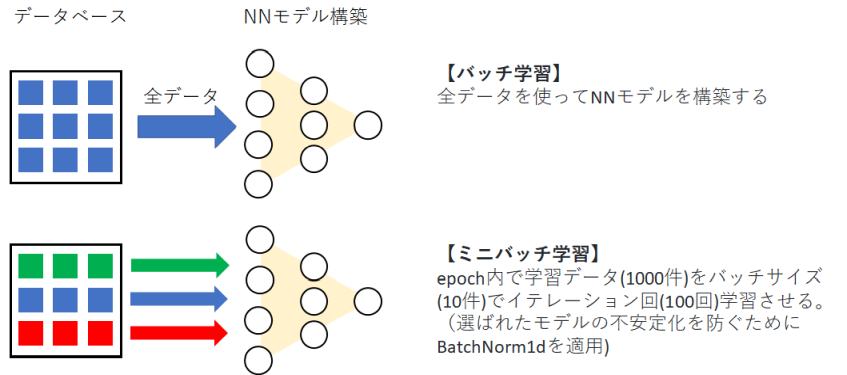<BR>
    
    
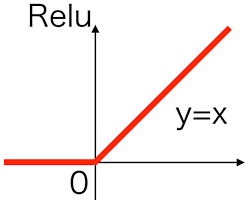

Modelの再定義

BatchNorm1d() 数値の規格化処理を実施 　回帰分析の結果をかなり良くすることがある。  （いつも有効とは限らないことに注意）<BR>
ReLU()  活性化関数処理<BR>

In [ ]:
model= nn.Sequential(
    nn.Linear(1784,128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64,16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    nn.Linear(16,1),
)

Minibatchの利用 loader

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(train_X, train_t)
loader = DataLoader(dataset,batch_size=64, shuffle=True)

In [ ]:
#optimizer = optim.SGD(model.parameters(), lr=0.001)  #model.parameters() 学習させたい変数　　ln は学習率
optimizer = optim.Adam(model.parameters(), lr=0.001)  #model.parameters() 学習させたい変数　　ln は学習率

In [ ]:
l
o
s
s
_
h
i
s
t
o
r
y
=
[
]

l
o
s
s
t
e
s
t
_
h
i
s
t
o
r
y
=
[
]


f
o
r
 
e
p
o
c
h
 
i
n
 
t
q
d
m
(
r
a
n
g
e
(
2
0
0
)
)
:

 
 
 
 
m
o
d
e
l
.
t
r
a
i
n
(
)

 
 
 
 
f
o
r
 
X
,
 
t
 
i
n
 
l
o
a
d
e
r
:

 
 
 
 
 
 
 
 
o
p
t
i
m
i
z
e
r
.
z
e
r
o
_
g
r
a
d
(
)
 
 
 
#
o
p
t
i
m
i
z
e
r
の
初
期
化

 
 
 
 
 
 
 
 
y
=
m
o
d
e
l
(
X
)

 
 
 
 
 
 
 
 
l
o
s
s
=
l
o
s
s
_
f
n
(
y
,
t
)

 
 
 
 
 
 
 
 
l
o
s
s
.
b
a
c
k
w
a
r
d
(
)
 
 
 
#
傾
き
を
計
算

 
 
 
 
 
 
 
 
o
p
t
i
m
i
z
e
r
.
s
t
e
p
(
)
 
 
 
#
更
新
処
理
実
施

 
 
 
 
 
 
 
 

 
 
 
 
l
o
s
s
_
h
i
s
t
o
r
y
.
a
p
p
e
n
d
(
f
l
o
a
t
(
l
o
s
s
)
)


 
 
 
 
#
 
テ
ス
ト
損
失
は
e
v
a
l
(
)
モ
ー
ド
で
評
価
（
B
a
t
c
h
N
o
r
m
 
の
挙
動
が
変
わ
る
た
め
）

 
 
 
 
m
o
d
e
l
.
e
v
a
l
(
)

 
 
 
 
w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
 
 
 
 
t
e
s
t
_
y
=
m
o
d
e
l
(
t
e
s
t
_
X
)

 
 
 
 
 
 
 
 
l
o
s
s
t
e
s
t
=
l
o
s
s
_
f
n
(
t
e
s
t
_
y
,
t
e
s
t
_
t
)

 
 
 
 
l
o
s
s
t
e
s
t
_
h
i
s
t
o
r
y
.
a
p
p
e
n
d
(
f
l
o
a
t
(
l
o
s
s
t
e
s
t
)
)


p
l
t
.
p
l
o
t
(
l
o
s
s
_
h
i
s
t
o
r
y
)
 
 
#
b
l
u
e

p
l
t
.
p
l
o
t
(
l
o
s
s
t
e
s
t
_
h
i
s
t
o
r
y
)
 
#
o
r
a
n
g
e



In [ ]:
m
o
d
e
l
.
e
v
a
l
(
)

w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
t
r
a
i
n
_
y
=
m
o
d
e
l
(
t
r
a
i
n
_
X
)

 
 
 
 
t
e
s
t
_
y
=
m
o
d
e
l
(
t
e
s
t
_
X
)


p
r
i
n
t
 
(
l
o
s
s
_
f
n
(
t
r
a
i
n
_
y
,
t
r
a
i
n
_
t
)
)

p
l
t
.
p
l
o
t
(
t
r
a
i
n
_
y
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
t
r
a
i
n
_
t
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
'
+
'
)


p
r
i
n
t
 
(
l
o
s
s
_
f
n
(
t
e
s
t
_
y
,
t
e
s
t
_
t
)
)

p
l
t
.
p
l
o
t
(
t
e
s
t
_
y
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
t
e
s
t
_
t
.
d
e
t
a
c
h
(
)
.
n
u
m
p
y
(
)
,
'
x
'
)